In [1]:
!pip install yfinance

In [2]:
!pip install yfinance hmmlearn

In [3]:
import sys
print(sys.executable)

/Users/vikasshukla/.pyenv/versions/3.11.6/bin/python


Training data shape: (1199, 2)
Training the Hidden Markov Model...
Hidden Markov Model training completed.


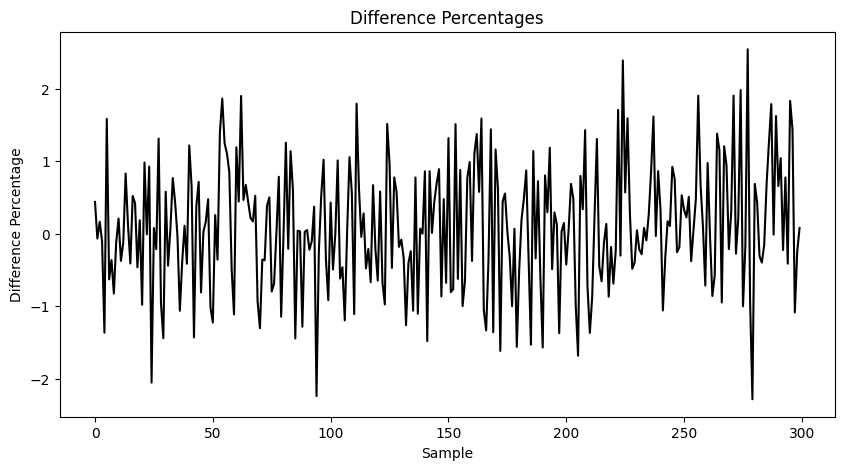

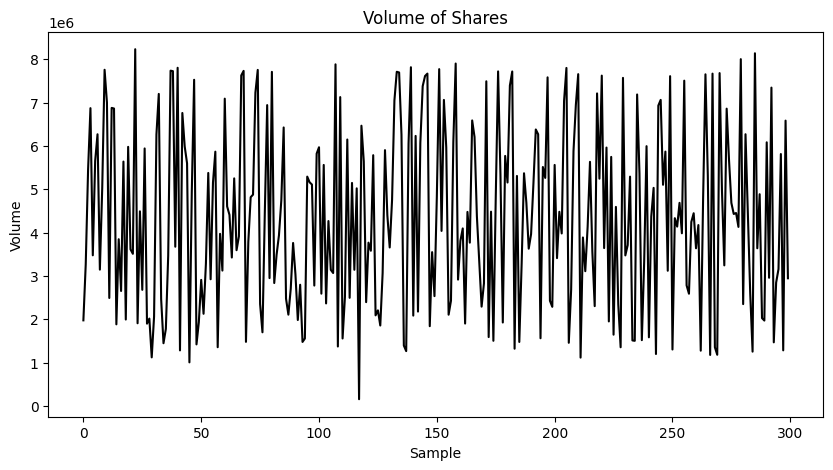

In [5]:
# Stock Market Analysis using Hidden Markov Model

import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

# Create sample stock-like data
np.random.seed(5)

num_days = 1200

# Generate synthetic closing prices
closing_quotes = 100 + np.cumsum(np.random.normal(0, 1, num_days))

# Generate synthetic volume values
volumes = np.random.randint(1000000, 8000000, num_days - 1)

# Calculate percentage difference in closing prices
diff_percentages = 100.0 * np.diff(closing_quotes) / closing_quotes[:-1]

# Stack difference percentage and volume values
training_data = np.column_stack([diff_percentages, volumes])

print("Training data shape:", training_data.shape)

# Create and train Gaussian HMM
hmm = GaussianHMM(
    n_components=7,
    covariance_type="diag",
    n_iter=1000,
    random_state=5
)

print("Training the Hidden Markov Model...")
hmm.fit(training_data)

print("Hidden Markov Model training completed.")

# Generate 300 samples
num_samples = 300
samples, _ = hmm.sample(num_samples)

# Plot generated difference percentages
plt.figure(figsize=(10, 5))
plt.title("Difference Percentages")
plt.plot(np.arange(num_samples), samples[:, 0], c="black")
plt.xlabel("Sample")
plt.ylabel("Difference Percentage")
plt.show()

# Plot generated volume values
plt.figure(figsize=(10, 5))
plt.title("Volume of Shares")
plt.plot(np.arange(num_samples), samples[:, 1], c="black")
plt.xlabel("Sample")
plt.ylabel("Volume")
plt.show()